# 📈 Task 2 — Quantitative Analysis Using PyNance and TA-Lib

This notebook loads multiple stock datasets, calculates technical indicators using TA-Lib, computes financial metrics using PyNance, and visualizes the results.


In [7]:
# In your notebook, install it in the current environment
%pip install pynance

import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import talib as ta
import pynance as pn

plt.style.use("ggplot")


  Using cached pynance-1.0.0-py3-none-any.whl.metadata (1.2 kB)
  Using cached pandas_datareader-0.10.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached mplfinance-0.12.10b0-py3-none-any.whl.metadata (19 kB)
  Using cached lxml-6.0.2-cp312-cp312-win_amd64.whl.metadata (3.7 kB)
Using cached pynance-1.0.0-py3-none-any.whl (42 kB)
Using cached pandas_datareader-0.10.0-py3-none-any.whl (109 kB)
Using cached mplfinance-0.12.10b0-py3-none-any.whl (75 kB)
Using cached lxml-6.0.2-cp312-cp312-win_amd64.whl (4.0 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## 🔹 Load All Stock CSV Files
We will load the following files from `data/raw/`:

- AAPL.csv  
- AMZN.csv  
- GOOG.csv  
- META.csv  
- MSFT.csv  
- NVDA.csv  


In [13]:
import os
import glob
import pandas as pd

# Correct relative path from notebooks folder
data_folder = r"..\data\raw"
file_pattern = os.path.join(data_folder, "*.csv")
file_paths = glob.glob(file_pattern)

print(f"Found {len(file_paths)} CSV files:")
for f in file_paths:
    print("-", f)

# Dictionary to store each stock DataFrame
stock_data = {}

for path in file_paths:
    # Extract stock name from filename
    name = os.path.basename(path).replace(".csv", "")
    
    # Read CSV
    df = pd.read_csv(path)
    
    # Standardize column names
    df.columns = [c.capitalize() for c in df.columns]
    
    # Convert 'Date' column to datetime if exists
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors='coerce')
    
    stock_data[name] = df

# Check loaded stocks
print("\nLoaded stock data for:", list(stock_data.keys()))


Found 7 CSV files:
- ..\data\raw\AAPL.csv
- ..\data\raw\AMZN.csv
- ..\data\raw\GOOG.csv
- ..\data\raw\META.csv
- ..\data\raw\MSFT.csv
- ..\data\raw\NVDA.csv
- ..\data\raw\raw_analyst_ratings.csv

Loaded stock data for: ['AAPL', 'AMZN', 'GOOG', 'META', 'MSFT', 'NVDA', 'raw_analyst_ratings']


In [6]:
import os
import pandas as pd
import numpy as np
import glob

# Detect correct path
project_root = os.path.dirname(os.getcwd())
data_path = os.path.join(project_root, "data", "raw")

file_paths = glob.glob(os.path.join(data_path, "*.csv"))

print("Found CSV files:", file_paths)

stock_data = {}

for path in file_paths:
    name = os.path.basename(path).replace(".csv", "")

    df = pd.read_csv(path)

    # Standardize formatting
    df.columns = [c.capitalize() for c in df.columns]

    if "Date" in df.columns:
        # Parse mixed datetime formats robustly:
        # - coerce unparsable strings to NaT
        # - convert all times to UTC for consistency (handles both tz-aware and tz-naive strings)
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce", utc=True)

    stock_data[name] = df

print("Loaded:", list(stock_data.keys()))


Found CSV files: ['c:\\Users\\Y\\Downloads\\financial-news-sentimental-analysis\\data\\raw\\AAPL.csv', 'c:\\Users\\Y\\Downloads\\financial-news-sentimental-analysis\\data\\raw\\AMZN.csv', 'c:\\Users\\Y\\Downloads\\financial-news-sentimental-analysis\\data\\raw\\GOOG.csv', 'c:\\Users\\Y\\Downloads\\financial-news-sentimental-analysis\\data\\raw\\META.csv', 'c:\\Users\\Y\\Downloads\\financial-news-sentimental-analysis\\data\\raw\\MSFT.csv', 'c:\\Users\\Y\\Downloads\\financial-news-sentimental-analysis\\data\\raw\\NVDA.csv', 'c:\\Users\\Y\\Downloads\\financial-news-sentimental-analysis\\data\\raw\\raw_analyst_ratings.csv']
Loaded: ['AAPL', 'AMZN', 'GOOG', 'META', 'MSFT', 'NVDA', 'raw_analyst_ratings']


## 🔹 Preview One Dataset
Let's display the first rows of AAPL.


In [14]:
stock_data["AAPL"].head()


,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


## 🔹 Apply Technical Indicators (TA-Lib)
We compute:
- SMA 20  
- SMA 50  
- RSI 14  
- MACD (12/26/9)
## Technical Indicators with TA-Lib

We use **TA-Lib** to calculate key technical indicators for each stock:

1. **Simple Moving Averages (SMA)** - 20-day and 50-day windows.
2. **Relative Strength Index (RSI)** - 14-day window to measure overbought/oversold conditions.
3. **MACD (Moving Average Convergence Divergence)** - trend-following momentum indicator, including MACD line, signal line, and histogram.

These indicators will help in visualizing trends and analyzing stock price movements.


In [17]:
import talib as ta

# Apply indicators to each stock
for name, df in stock_data.items():
    if {"Open", "High", "Low", "Close"}.issubset(df.columns):

        # Simple Moving Averages
        df["SMA_20"] = ta.SMA(df["Close"], timeperiod=20)
        df["SMA_50"] = ta.SMA(df["Close"], timeperiod=50)

        # Relative Strength Index
        df["RSI_14"] = ta.RSI(df["Close"], timeperiod=14)

        # MACD
        macd, signal, hist = ta.MACD(df["Close"], fastperiod=12, slowperiod=26, signalperiod=9)
        df["MACD"] = macd
        df["MACD_signal"] = signal
        df["MACD_hist"] = hist

        # Save back to dictionary
        stock_data[name] = df

        # Print confirmation
        print(f"{name} indicators added")


AAPL indicators added
AMZN indicators added
GOOG indicators added
META indicators added
MSFT indicators added
NVDA indicators added


## 🔹 Financial metrics (returns & volatility)
Compute daily returns and 20-day annualized volatility.

## Financial Metrics with NumPy (Return & Volatility)

Now we compute:
- **Daily Returns** using percentage change of Close price.
- **20-Day Annualized Volatility** using rolling standard deviation scaled by √252.

These metrics help assess the risk and behavior of each stock.



In [8]:
# Make sure stock_data exists before running this cell
print("Keys inside stock_data:", list(stock_data.keys()))

for name, df in stock_data.items():
    # Skip entries that don't look like price data
    if "Close" not in df.columns:
        print(f"Skipping '{name}': no 'Close' column")
        continue

    if df["Close"].dropna().empty:
        print(f"Skipping '{name}': 'Close' column is empty")
        continue

    # Work on a copy to avoid SettingWithCopyWarning
    df = df.copy()

    # Calculate daily returns
    df["Return"] = df["Close"].pct_change()

    # 20-Day Annualized Volatility (rolling window)
    df["Volatility_20"] = df["Return"].rolling(window=20).std() * np.sqrt(252)

    # Save back
    stock_data[name] = df

print("\nAdded Return & Volatility to all applicable stocks.")

# Show sample output if AAPL exists and has the computed columns
if "AAPL" in stock_data and {"Date", "Close", "Return", "Volatility_20"}.issubset(stock_data["AAPL"].columns):
    display(stock_data["AAPL"][["Date", "Close", "Return", "Volatility_20"]].head())
else:
    print("AAPL sample not available or missing required columns.")


Keys inside stock_data: ['AAPL', 'AMZN', 'GOOG', 'META', 'MSFT', 'NVDA', 'raw_analyst_ratings']
Skipping 'raw_analyst_ratings': no 'Close' column

Added Return & Volatility to all applicable stocks.


,Date,Close,Return,Volatility_20
0,2009-01-02 00:00:00+00:00,2.721686,NaN,NaN
1,2009-01-05 00:00:00+00:00,2.836553,0.042204,NaN
2,2009-01-06 00:00:00+00:00,2.789767,-0.016494,NaN
3,2009-01-07 00:00:00+00:00,2.729484,-0.021609,NaN
4,2009-01-08 00:00:00+00:00,2.780169,0.018570,NaN


## 🔹 Visualize: Price with SMA 20 & SMA 50 (AAPL example)


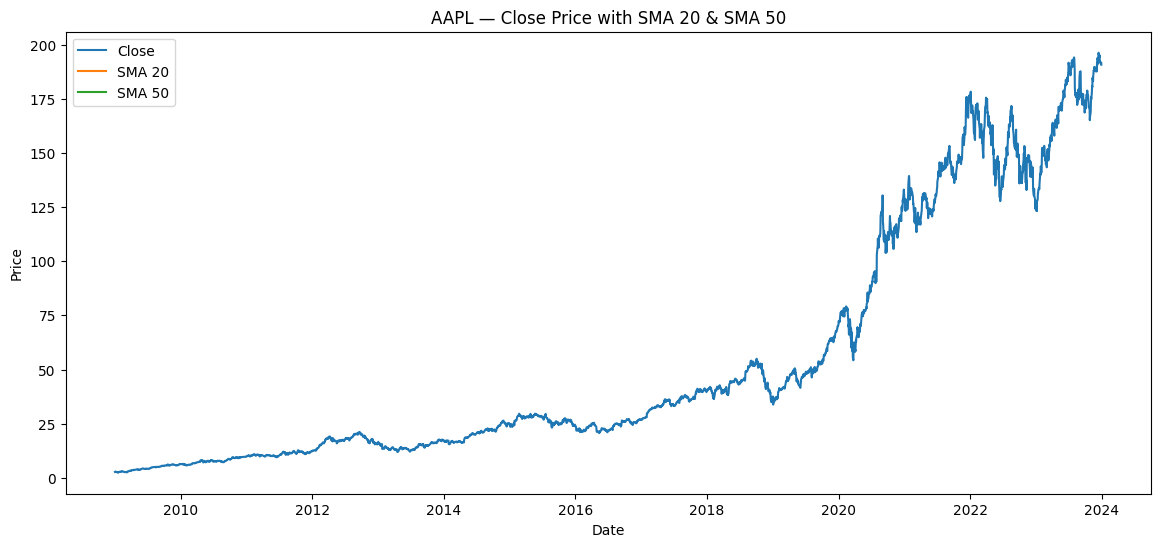

In [12]:
# Recreate aapl_df to ensure it includes the technical indicators
aapl_df = stock_data["AAPL"].dropna(subset=["Date"])

plt.figure(figsize=(14,6))
plt.plot(aapl_df["Date"], aapl_df["Close"], label="Close")
plt.plot(aapl_df["Date"], aapl_df.get("SMA_20", pd.Series([None]*len(aapl_df))), label="SMA 20")
plt.plot(aapl_df["Date"], aapl_df.get("SMA_50", pd.Series([None]*len(aapl_df))), label="SMA 50")
plt.title("AAPL — Close Price with SMA 20 & SMA 50")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


## 🔹 Visualize: RSI (AAPL)


In [18]:
import talib

# Calculate indicators for all stocks in stock_data
for name, df in stock_data.items():
    # Only process DataFrames with a 'Close' column
    if "Close" not in df.columns:
        print(f"Skipping '{name}': no 'Close' column")
        continue

    df = df.dropna(subset=["Date"])

    # Simple Moving Averages
    df["SMA_20"] = talib.SMA(df["Close"], timeperiod=20)
    df["SMA_50"] = talib.SMA(df["Close"], timeperiod=50)

    # RSI
    df["RSI_14"] = talib.RSI(df["Close"], timeperiod=14)

    # Save back
    stock_data[name] = df


Skipping 'raw_analyst_ratings': no 'Close' column


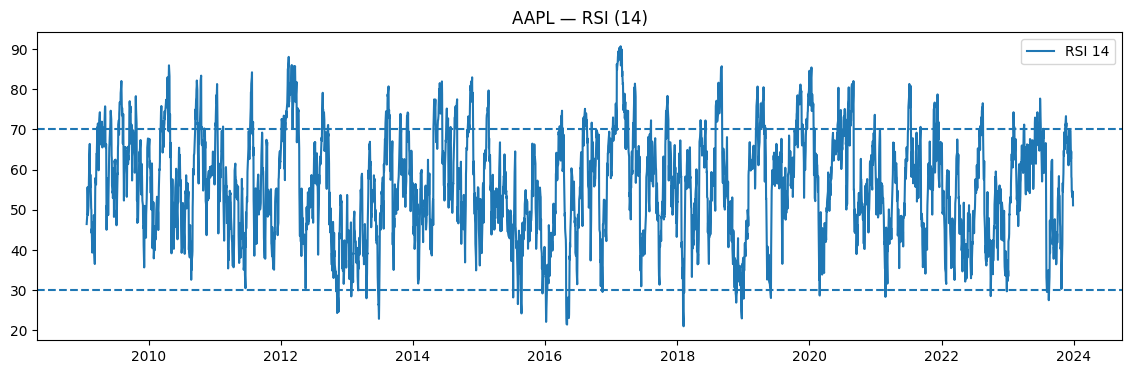

In [19]:
aapl_df = stock_data["AAPL"].dropna(subset=["Date"])

if "RSI_14" in aapl_df.columns:
    plt.figure(figsize=(14,4))
    plt.plot(aapl_df["Date"], aapl_df["RSI_14"], label="RSI 14")
    plt.axhline(70, linestyle="--")
    plt.axhline(30, linestyle="--")
    plt.title("AAPL — RSI (14)")
    plt.legend()
    plt.show()
else:
    print("RSI_14 column not found.")


## 🔹 Visualize: MACD (AAPL)


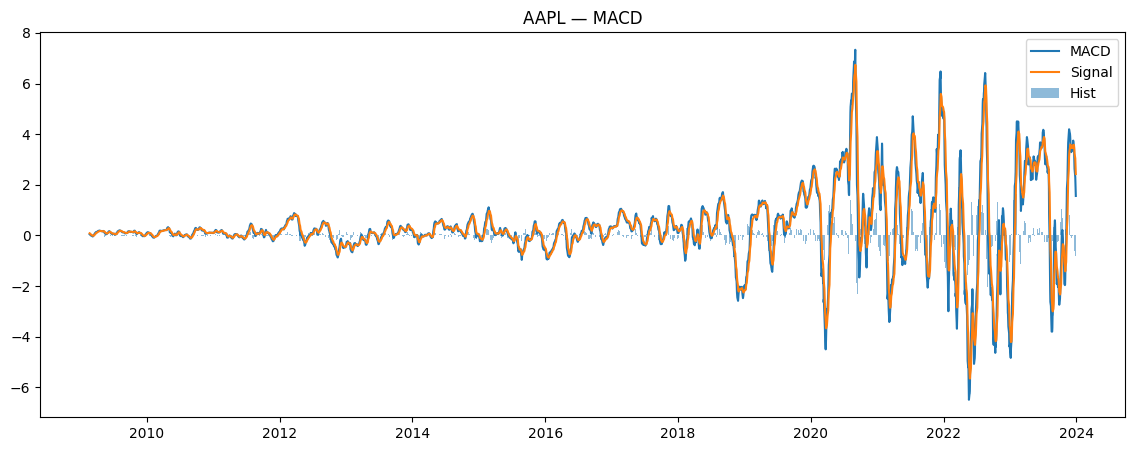

In [23]:
# ensure TA-Lib is available in this cell's namespace
import talib as ta

# Ensure MACD columns exist before plotting (compute if missing)
if not {"MACD", "MACD_signal", "MACD_hist"}.issubset(aapl_df.columns):
	# use TA-Lib already imported as `ta`
	macd, signal, hist = ta.MACD(aapl_df["Close"], fastperiod=12, slowperiod=26, signalperiod=9)
	aapl_df = aapl_df.copy()
	aapl_df["MACD"] = macd
	aapl_df["MACD_signal"] = signal
	aapl_df["MACD_hist"] = hist
	# update stored dataframe so other cells see the new columns
	stock_data["AAPL"] = aapl_df

plt.figure(figsize=(14,5))
plt.plot(aapl_df["Date"], aapl_df["MACD"], label="MACD")
plt.plot(aapl_df["Date"], aapl_df["MACD_signal"], label="Signal")
plt.bar(aapl_df["Date"], aapl_df["MACD_hist"], label="Hist", width=1, alpha=0.5)
plt.title("AAPL — MACD")
plt.legend()
plt.show()


## 🔹 (Optional) Save plots for all stocks


In [27]:
outdir = "outputs/plots"
os.makedirs(outdir, exist_ok=True)

for name, df in stock_data.items():

    required_cols = {"Close", "SMA_20", "SMA_50", "Date"}
    if not required_cols.issubset(df.columns):
        print(f"Skipping: {name} (missing price columns)")
        continue

    df = df.dropna(subset=["Date"])

    plt.figure(figsize=(12,5))
    plt.plot(df["Date"], df["Close"], label="Close")
    plt.plot(df["Date"], df["SMA_20"], label="SMA 20")
    plt.plot(df["Date"], df["SMA_50"], label="SMA 50")

    plt.title(f"{name} — Close & SMAs")
    plt.legend()
    plt.savefig(f"{outdir}/{name}_price_sma.png", bbox_inches="tight")
    plt.close()

print("Done!")


Skipping: raw_analyst_ratings (missing price columns)
Done!
